# Per-Format Validation Analysis
Addresses reviewer comments: per-format MAPE, spread statistics (StdDev/CV), no APE-best.


In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cbook import boxplot_stats
from scipy.stats import hmean as scipy_hmean
import subprocess, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
# Publication settings
width = 3.487
height = width / 1.618
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 7})

palette = ['#4daf4a','#e41a1c','#984ea3','#377eb8','#ff7f00']
ranges_dev = ['NVIDIA-H100', 'AMD-MI250', 'AMD-EPYC-64', 'INTEL-SAPPHIRE-56', 'ARM-GRACE-72']
color_dictionary = dict(zip(ranges_dev, palette))

def change_colors(devs, cdict):
    sns.set_palette([v for k,v in cdict.items() if k in devs])

change_colors(ranges_dev, color_dictionary)


In [3]:
# Format name mapping (from benchmark_aggregation.ipynb)
format_name_mapping = {
    'cuSPARSE_csr11': 'cu-CSR', 'cuSPARSE_coo11': 'cu-COO', 'cuSPARSE_hyb9-2': 'cu-HYB',
    'CUSPARSE_CSR': 'cu-CSR', 'CUSPARSE_COO': 'cu-COO',
    'ROCSPARSE_CSR': 'roc-CSR', 'ROCSPARSE_COO': 'roc-COO', 'ROCSPARSE_HYB': 'roc-HYB',
    'Merge_11': 'Merge-CSR', 'MERGE_CUDA': 'Merge-CSR', 'MERGE': 'Merge-CSR',
    'Custom_CSR_CUDA_ADAPTIVE_b512_1': 'Ada-CSR', 'Custom_CSR_CUDA_ADAPTIVE_b256_1': 'Ada-CSR',
    'Custom_CSR_ROCM_ADAPTIVE_b512_1': 'Ada-CSR',
    'Custom_CSR_CUDA_VECTOR_b256': 'Vec-CSR', 'Custom_CSR_ROCM_VECTOR_b512': 'Vec-CSR',
    'Custom_CSR_CUDA_constant_nnz_per_thread_b1024_nnz4': 'Custom-CSR',
    'Custom_CSR_ROCM_constant_nnz_per_thread_b512_nnz4': 'Custom-CSR',
    'ACC_LINE_ENHANCE_b512': 'ACC-Line', 'ACC_FLAT_b512': 'ACC-Flat',
    'SELL-32-1': 'SELL-C-σ', 'Naive_CSR_CPU': 'Naive-CSR',
    'Custom_CSR_B': 'Bal-CSR', 'Custom_CSR_BV_x86': 'Vec-CSR', 'Custom_CSR_BV_SVE': 'Vec-CSR',
    'Custom_CSR_PBV': 'Custom_CSR_BV',
    'MKL_IE': 'MKL-IE', 'AOCL_OPTMV': 'AOCL', 'ARMPL': 'ARM-lib',
    'SparseX': 'SparseX', 'CSR5_9': 'CSR5', 'CSR5_CUDA': 'CSR5', 'CSR5': 'CSR5',
    'DASP_CUDA': 'DASP', 'LCM': 'LCM',
}


In [4]:
# Load data
df_real_all = pd.read_csv('validation_real_benchmarks_all-devices_all.csv')
df_friends_all = pd.read_csv('validation_friends_benchmarks_all-devices_all.csv')
print(f'Real: {df_real_all.shape}, Friends: {df_friends_all.shape}')

# Apply format mapping to real data
df_real_all['format_name'] = df_real_all['format_name'].replace(format_name_mapping)

# Filter devices & exclude matrices
exclude_matrices = ['mawi_201512012345', 'kmer_V2a']
df_real_all = df_real_all[df_real_all['System'].isin(ranges_dev) & ~df_real_all['matrix_name'].isin(exclude_matrices)]
df_friends_all = df_friends_all[df_friends_all['System'].isin(ranges_dev)]

# Dedup: if multiple raw names map to same short name for same (matrix, device, format), keep best
df_real_all = df_real_all.loc[df_real_all.groupby(['matrix_name','System','format_name'])['gflops'].idxmax()].reset_index(drop=True)
print(f'After filter+dedup => Real: {df_real_all.shape}, Friends: {df_friends_all.shape}')
print(f'Unique real matrices: {df_real_all["matrix_name"].nunique()}')


Real: (4228, 32), Friends: (268041, 30)
After filter+dedup => Real: (2048, 32), Friends: (137210, 30)
Unique real matrices: 50


---
# Format Filtering Analysis
Here we analyze the "Win Share" (how often a format is the best) globally and per-device.
This helps identify which formats are rarely optimal and might just be adding noise.



In [5]:
# 1. Global Win Share
best_formats_global = df_real_all.loc[df_real_all.groupby(['System','matrix_name'])['gflops'].idxmax()]['format_name']
global_win_counts = best_formats_global.value_counts().reset_index()
global_win_counts.columns = ['format_name', 'total_wins']

total_cases = len(best_formats_global)
global_win_counts['global_win_share_%'] = (global_win_counts['total_wins'] / total_cases) * 100

print(f"Total evaluated cases (devices x matrices): {total_cases}")
print("\n" + "="*50)
print("[Global Win Share by Format]")
print("="*50)
print(global_win_counts.to_string(index=False))

# 2. Per-Device Win Share
print("\n" + "="*50)
print("[Per-Device Win Share by Format]")
print("="*50)

for dev in ranges_dev:
    real_dev = df_real_all[df_real_all['System'] == dev]
    best_dev = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()]['format_name']
    dev_counts = best_dev.value_counts().reset_index()
    dev_counts.columns = ['format_name', 'wins']
    total_dev = len(best_dev)
    dev_counts['win_share_%'] = (dev_counts['wins'] / total_dev) * 100
    print(f"\n--- {dev} ({total_dev} matrices) ---")
    print(dev_counts.to_string(index=False))


Total evaluated cases (devices x matrices): 250

[Global Win Share by Format]
format_name  total_wins  global_win_share_%
    Vec-CSR          59                23.6
    roc-CSR          34                13.6
     cu-CSR          34                13.6
     MKL-IE          31                12.4
  Merge-CSR          26                10.4
       DASP          11                 4.4
    SparseX          10                 4.0
   ACC-Flat          10                 4.0
    ARM-lib           8                 3.2
   SELL-C-σ           5                 2.0
        LCM           4                 1.6
    Bal-CSR           3                 1.2
       CSR5           3                 1.2
    roc-HYB           3                 1.2
  Naive-CSR           3                 1.2
    Ada-CSR           2                 0.8
    roc-COO           1                 0.4
   ACC-Line           1                 0.4
       AOCL           1                 0.4
     cu-COO           1                 0.

---
# Format Filtering
We dynamically drop any format that achieves less than 10% win share on a specific device, as they are not optimal formats for that architecture.

In [6]:
# Apply filtering
apply_filtering = False

if(apply_filtering):
    # Per-device format filtering based on <5% win share
    bad_system_formats = []
    for dev in ranges_dev:
        real_dev = df_real_all[df_real_all['System'] == dev]
        if real_dev.empty: continue
        
        # Get the best format for each matrix
        best_dev = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()]['format_name']
        
        # Calculate win share
        dev_counts = best_dev.value_counts().reset_index()
        dev_counts.columns = ['format_name', 'wins']
        total_dev = len(best_dev)
        dev_counts['win_share_%'] = (dev_counts['wins'] / total_dev) * 100
        
        # Formats with < 10% win share on this device
        # bad_formats = dev_counts[dev_counts['win_share_%'] < 10.0]['format_name'].tolist()
        bad_formats = dev_counts[dev_counts['win_share_%'] < 5.0]['format_name'].tolist()
        
        # Also find any format that NEVER won (0 wins)
        all_dev_formats = real_dev['format_name'].unique()
        for fmt in all_dev_formats:
            if fmt not in dev_counts['format_name'].values:
                bad_formats.append(fmt)
                
        for bf in set(bad_formats): # Use set to avoid duplicates
            bad_system_formats.append((dev, bf))
    
    print("Filtering out the following (System, Format) pairs due to < 10% win share:")
    for dev, bf in bad_system_formats:
        print(f"  {dev}: {bf}")

    mask_real = pd.Series([True]*len(df_real_all))
    mask_friends = pd.Series([True]*len(df_friends_all))
    
    for dev, bf in bad_system_formats:
        mask_real = mask_real & ~((df_real_all['System'] == dev) & (df_real_all['format_name'] == bf))
        mask_friends = mask_friends & ~((df_friends_all['System'] == dev) & (df_friends_all['format_name'] == bf))
    
    df_real_all = df_real_all[mask_real].reset_index(drop=True)
    df_friends_all = df_friends_all[mask_friends].reset_index(drop=True)
    
    print(f"\nRemaining data rows: Real={len(df_real_all)}, Friends={len(df_friends_all)}")


---
# Friend extraction methods (bounding box, knn, weighted knn, soft box, pca)

In [7]:
# Feature matching (reused from validation.ipynb)
llc_threshold = {'AMD-EPYC-64': 256, 'INTEL-SAPPHIRE-56': 105, 'ARM-GRACE-72': 114}
FEATURES = ['nr_rows', 'avg_nnz_per_row', 'skew', 'cross_row_similarity', 'avg_num_neighbours']

def get_em_feats(pcg, features, dataframe, row, threshold=1):
    low, high = 1 - pcg*0.01, 1 + pcg*0.01
    feature_boolean = pd.Series(True, index=dataframe.index)
    for i, feature in enumerate(features):
        fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]*high) & (dataframe[feature] >= row[feature]*low)
        isol = dataframe[fb_tmp]
        skew_threshold = 5
        if feature == 'skew' and row[feature] < skew_threshold:
            fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]+skew_threshold) & (dataframe[feature] >= row[feature]-skew_threshold)
            isol = dataframe[fb_tmp]
        pcg2_limit, pcg2 = 45, pcg
        if feature in ('avg_num_neighbours', 'cross_row_similarity'):
            while isol.shape[0] < threshold:
                pcg2 += 1
                if pcg2 > pcg2_limit: break
                low2, high2 = 1-pcg2*0.01, 1+pcg2*0.01
                fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]*high2) & (dataframe[feature] >= row[feature]*low2)
                isol = dataframe[fb_tmp]
            reg_threshold = 0.04
            if row[feature] < 0.1 and isol.shape[0] < threshold:
                fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]+reg_threshold) & (dataframe[feature] >= row[feature]-reg_threshold)
                isol = dataframe[fb_tmp]
        feature_boolean = fb_tmp
    return dataframe[feature_boolean]

def find_friends_bounding_box(row, friends_device, system, threshold=10):
    """Find feature-matched friends using original bounding box logic."""
    # Deduplicate friends for feature matching (one row per unique friend matrix)
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    friends_dedup = friends_device.drop_duplicates(subset=dedup_cols)
    matched_dedup = get_em_feats(30, FEATURES, friends_dedup, row, threshold)
    # LLC filtering for CPUs
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            matched_dedup = matched_dedup[matched_dedup['mem_footprint'] < llc_threshold[system]]
        else:
            matched_dedup = matched_dedup[matched_dedup['mem_footprint'] > llc_threshold[system]]
    # Join back to get all format rows for matched friends
    matched_keys = matched_dedup[dedup_cols]
    matched_friends = friends_device.merge(matched_keys, on=dedup_cols, how='inner')
    return matched_friends

def find_friends_knn(row, friends_device, system, k=50):
    """Find the top-K most structurally similar friends using Euclidean distance in a Z-score normalized feature space."""
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    friends_dedup = friends_device.drop_duplicates(subset=dedup_cols).copy()
    
    # LLC filtering for CPUs
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] < llc_threshold[system]]
        else:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] > llc_threshold[system]]
            
    if friends_dedup.empty:
        return pd.DataFrame()
        
    X_friends = friends_dedup[FEATURES].values.astype(np.float64)
    X_real = row[FEATURES].values.reshape(1, -1).astype(np.float64)
    X_all = np.vstack([X_real, X_friends])
    
    means = np.mean(X_all, axis=0)
    stds = np.std(X_all, axis=0) + 1e-9
    X_all_normalized = (X_all - means) / stds
    
    X_real_norm = X_all_normalized[0]
    X_friends_norm = X_all_normalized[1:]
    distances = np.linalg.norm(X_friends_norm - X_real_norm, axis=1)
    
    n_friends_to_keep = min(k, len(distances))
    top_k_indices = np.argsort(distances)[:n_friends_to_keep]
    
    matched_dedup = friends_dedup.iloc[top_k_indices].copy()
    matched_keys = matched_dedup[dedup_cols]
    matched_friends = friends_device.merge(matched_keys, on=dedup_cols, how='inner')
    return matched_friends

def find_friends_weighted_knn(row, friends_device, system, k=60):
    """Find top-K friends using weighted Euclidean distance in Z-score normalized space."""
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    friends_dedup = friends_device.drop_duplicates(subset=dedup_cols).copy()
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] < llc_threshold[system]]
        else:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] > llc_threshold[system]]
    if friends_dedup.empty:
        return pd.DataFrame()
    
    # Weights: emphasize avg_nnz_per_row and nr_rows
    weights = np.array([1.5, 2.0, 0.5, 0.8, 1.0])
    
    X_friends = friends_dedup[FEATURES].values.astype(np.float64)
    X_real = row[FEATURES].values.reshape(1, -1).astype(np.float64)
    X_all = np.vstack([X_real, X_friends])
    
    means = np.mean(X_all, axis=0)
    stds = np.std(X_all, axis=0) + 1e-9
    X_all_normalized = (X_all - means) / stds
    X_all_weighted = X_all_normalized * weights
    
    X_real_norm = X_all_weighted[0]
    X_friends_norm = X_all_weighted[1:]
    distances = np.linalg.norm(X_friends_norm - X_real_norm, axis=1)
    
    n_friends_to_keep = min(k, len(distances))
    top_k_indices = np.argsort(distances)[:n_friends_to_keep]
    
    matched_dedup = friends_dedup.iloc[top_k_indices].copy()
    matched_keys = matched_dedup[dedup_cols]
    return friends_device.merge(matched_keys, on=dedup_cols, how='inner')

def find_friends_soft_box(row, friends_device, system, target_friends=30):
    """Find friends using a uniformly expanding bounding box (max relative error)."""
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    friends_dedup = friends_device.drop_duplicates(subset=dedup_cols).copy()
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] < llc_threshold[system]]
        else:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] > llc_threshold[system]]
    if friends_dedup.empty:
        return pd.DataFrame()
        
    X_friends = friends_dedup[FEATURES].values.astype(np.float64)
    X_real = row[FEATURES].values.reshape(1, -1).astype(np.float64)
    
    rel_errors = np.abs(X_friends - X_real) / np.maximum(X_real, 1e-9)
    skew_idx = FEATURES.index('skew')
    if row['skew'] < 5:
        rel_errors[:, skew_idx] = np.abs(X_friends[:, skew_idx] - X_real[0, skew_idx]) / 5.0
        
    max_errors = np.max(rel_errors, axis=1)
    
    threshold = 0.30
    while True:
        valid_indices = np.where(max_errors <= threshold)[0]
        if len(valid_indices) >= target_friends or threshold >= 1.0:
            break
        threshold += 0.05
        
    matched_dedup = friends_dedup.iloc[valid_indices].copy()
    matched_keys = matched_dedup[dedup_cols]
    return friends_device.merge(matched_keys, on=dedup_cols, how='inner')

def find_friends_pca(row, friends_device, system, k=60):
    """Find top-K friends using distance in PCA-reduced space."""
    try:
        from sklearn.decomposition import PCA
    except ImportError:
        print("sklearn not installed, falling back to KNN")
        return find_friends_knn(row, friends_device, system, k)
        
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    friends_dedup = friends_device.drop_duplicates(subset=dedup_cols).copy()
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] < llc_threshold[system]]
        else:
            friends_dedup = friends_dedup[friends_dedup['mem_footprint'] > llc_threshold[system]]
    if friends_dedup.empty:
        return pd.DataFrame()
        
    X_friends = friends_dedup[FEATURES].values.astype(np.float64)
    X_real = row[FEATURES].values.reshape(1, -1).astype(np.float64)
    X_all = np.vstack([X_real, X_friends])
    
    means = np.mean(X_all, axis=0)
    stds = np.std(X_all, axis=0) + 1e-9
    X_all_normalized = (X_all - means) / stds
    
    pca = PCA(n_components=min(3, len(FEATURES)))
    X_pca = pca.fit_transform(X_all_normalized)
    
    X_real_pca = X_pca[0]
    X_friends_pca = X_pca[1:]
    distances = np.linalg.norm(X_friends_pca - X_real_pca, axis=1)
    
    n_friends_to_keep = min(k, len(distances))
    top_k_indices = np.argsort(distances)[:n_friends_to_keep]
    
    matched_dedup = friends_dedup.iloc[top_k_indices].copy()
    matched_keys = matched_dedup[dedup_cols]
    return friends_device.merge(matched_keys, on=dedup_cols, how='inner')


def find_friends_hierarchical(row, friends_device, system, k=60):
    """Hierarchical 3-stage matching to find the top-K closest artificial matrices.
    
    Stage 0: LLC filtering for CPUs
    Stage 1: Structural filter -- avg_num_neighbours + cross_row_similarity (hard filter)
    Stage 1b: nr_rows hard constraint (0.33x to 3.0x)
    Stage 2: Size/density ranking -- nr_rows + avg_nnz_per_row (relative difference)
    Stage 3: Skew tiebreaker -- log-scale distance
    """
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    candidates = friends_device.drop_duplicates(subset=dedup_cols).copy()
    
    # ---- Stage 0: LLC filtering for CPUs ----
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            candidates = candidates[candidates['mem_footprint'] < llc_threshold[system]]
        else:
            candidates = candidates[candidates['mem_footprint'] > llc_threshold[system]]
    
    if candidates.empty:
        return pd.DataFrame()
    
    # ---- Stage 1: Structural filter (avg_num_neighbours + cross_row_similarity) ----
    structural_features = ['avg_num_neighbours', 'cross_row_similarity']
    stage1_tolerance = 0.35  # +/-35% relative tolerance
    stage1_abs_fallback = 0.05  # absolute tolerance when real value is very small
    
    stage1_mask = pd.Series(True, index=candidates.index)
    for feat in structural_features:
        real_val = row[feat]
        if abs(real_val) < 0.1:
            stage1_mask = stage1_mask & (candidates[feat] >= real_val - stage1_abs_fallback) & \
                                        (candidates[feat] <= real_val + stage1_abs_fallback)
        else:
            lo = real_val * (1 - stage1_tolerance)
            hi = real_val * (1 + stage1_tolerance)
            stage1_mask = stage1_mask & (candidates[feat] >= lo) & (candidates[feat] <= hi)
    
    survivors = candidates[stage1_mask]
    
    # Fallback: progressively widen tolerance
    widen_step = 0.10
    while survivors.empty and stage1_tolerance < 1.0:
        stage1_tolerance += widen_step
        stage1_mask = pd.Series(True, index=candidates.index)
        for feat in structural_features:
            real_val = row[feat]
            if abs(real_val) < 0.1:
                abs_tol = stage1_abs_fallback + (stage1_tolerance - 0.35) * 0.1
                stage1_mask = stage1_mask & (candidates[feat] >= real_val - abs_tol) & \
                                            (candidates[feat] <= real_val + abs_tol)
            else:
                lo = real_val * (1 - stage1_tolerance)
                hi = real_val * (1 + stage1_tolerance)
                stage1_mask = stage1_mask & (candidates[feat] >= lo) & (candidates[feat] <= hi)
        survivors = candidates[stage1_mask]
    
    if survivors.empty:
        survivors = candidates
    
    # ---- Stage 1b: nr_rows hard constraint (prevent extreme size mismatches) ----
    real_nr = row['nr_rows']
    nr_rows_mask = (survivors['nr_rows'] >= real_nr * 0.33) & (survivors['nr_rows'] <= real_nr * 3.0)
    nr_rows_filtered = survivors[nr_rows_mask]
    if not nr_rows_filtered.empty:
        survivors = nr_rows_filtered
    
    # ---- Stage 2: Size/density ranking (relative difference) ----
    real_nr_rows = max(row['nr_rows'], 1e-9)
    real_avg_nnz = max(row['avg_nnz_per_row'], 1e-9)
    
    rel_diff_nr_rows = np.abs(survivors['nr_rows'].values - real_nr_rows) / real_nr_rows
    rel_diff_avg_nnz = np.abs(survivors['avg_nnz_per_row'].values - real_avg_nnz) / real_avg_nnz
    
    size_distances = rel_diff_nr_rows + rel_diff_avg_nnz
    
    # ---- Stage 3: Skew tiebreaker (log-scale) ----
    real_skew = row['skew']
    friend_skews = survivors['skew'].values.astype(np.float64)
    
    skew_distances = np.abs(np.log1p(np.abs(friend_skews)) - np.log1p(np.abs(real_skew)))
    
    skew_max = skew_distances.max() + 1e-9
    skew_norm = skew_distances / skew_max
    
    size_max = size_distances.max() + 1e-9
    size_norm = size_distances / size_max
    
    SKEW_WEIGHT = 0.25
    combined_score = size_norm + SKEW_WEIGHT * skew_norm
    
    # Pick top-K closest
    n_to_keep = min(k, len(combined_score))
    top_k_indices = np.argsort(combined_score)[:n_to_keep]
    
    matched_dedup = survivors.iloc[top_k_indices].copy()
    matched_keys = matched_dedup[dedup_cols]
    matched_friends = friends_device.merge(matched_keys, on=dedup_cols, how='inner')
    return matched_friends

# ==============================================================================
# STRATEGY SELECTION
# Set to 'bounding_box', 'knn', 'weighted_knn', 'soft_box', 'pca', or 'hierarchical'
# FRIEND_EXTRACTION_METHOD = 'knn'
# FRIEND_EXTRACTION_METHOD = 'bounding_box'
# FRIEND_EXTRACTION_METHOD = 'soft_box'
FRIEND_EXTRACTION_METHOD = 'hierarchical'

TARGET_FRIENDS_COUNT = 60
# TARGET_FRIENDS_COUNT = 30
# ==============================================================================

def find_friends_for_matrix(row, friends_device, system, threshold=10):
    """Wrapper function to easily switch between extraction strategies."""
    if FRIEND_EXTRACTION_METHOD == 'knn':
        return find_friends_knn(row, friends_device, system, k=TARGET_FRIENDS_COUNT)
    elif FRIEND_EXTRACTION_METHOD == 'weighted_knn':
        return find_friends_weighted_knn(row, friends_device, system, k=TARGET_FRIENDS_COUNT)
    elif FRIEND_EXTRACTION_METHOD == 'soft_box':
        return find_friends_soft_box(row, friends_device, system, target_friends=TARGET_FRIENDS_COUNT)
    elif FRIEND_EXTRACTION_METHOD == 'pca':
        return find_friends_pca(row, friends_device, system, k=TARGET_FRIENDS_COUNT)
    elif FRIEND_EXTRACTION_METHOD == 'hierarchical':
        return find_friends_hierarchical(row, friends_device, system, k=TARGET_FRIENDS_COUNT)
    else:
        res = find_friends_bounding_box(row, friends_device, system, threshold)
        if len(res) > TARGET_FRIENDS_COUNT:
            res = res.head(TARGET_FRIENDS_COUNT)
        return res


---
# Per-Format Error Computation



In [8]:
def compute_per_format_errors(ranges_dev, df_real_all, df_friends_all):
    """Core analysis: compute per-(device, matrix, format) errors."""
    all_results = []
    for system in ranges_dev:
        print(f'\n=== {system} ===')
        real_dev = df_real_all[df_real_all['System'] == system].sort_values('mem_footprint')
        friends_dev = df_friends_all[df_friends_all['System'] == system]
        real_matrices = real_dev['matrix_name'].unique()
        for mtx in real_matrices:
            real_mtx = real_dev[real_dev['matrix_name'] == mtx]
            row_ref = real_mtx.iloc[0]  # features are same across formats
            matched_friends = find_friends_for_matrix(row_ref, friends_dev, system)
            n_unique_friends = matched_friends.drop_duplicates(
                subset=['nr_rows','nr_cols','nr_nzeros']).shape[0]
            # Per format
            real_formats = set(real_mtx['format_name'])
            friend_formats = set(matched_friends['format_name'])
            common_formats = real_formats & friend_formats
            for fmt in common_formats:
                real_gflops = real_mtx[real_mtx['format_name']==fmt]['gflops'].values[0]
                friend_gflops = matched_friends[matched_friends['format_name']==fmt]['gflops'].values
                if real_gflops <= 0 or len(friend_gflops) == 0:
                    continue
                apes = np.abs(friend_gflops - real_gflops) / real_gflops * 100
                mape = np.mean(apes)
                median_ape = np.median(apes)
                std_gflops = np.std(friend_gflops)
                # Harmonic mean for rates (Hoefler Rule 3)
                positive_gflops = friend_gflops[friend_gflops > 0]
                mean_gflops = scipy_hmean(positive_gflops) if len(positive_gflops) > 0 else 0
                cv = (std_gflops / mean_gflops * 100) if mean_gflops > 0 else 0
                median_gflops = np.median(friend_gflops)
                all_results.append({
                    'System': system, 'matrix_name': mtx, 'format_name': fmt,
                    'real_gflops': real_gflops, 'n_friends': len(friend_gflops),
                    'n_unique_friends': n_unique_friends,
                    'friend_mean': mean_gflops, 'friend_median': median_gflops,
                    'friend_std': std_gflops, 'MAPE': mape, 'MedAPE': median_ape, 'CV': cv,
                    'mem_footprint': row_ref['mem_footprint'],
                })
        print(f'  {len(real_matrices)} matrices processed')
    return pd.DataFrame(all_results)

results_df = compute_per_format_errors(ranges_dev, df_real_all, df_friends_all)
print(f'\nTotal results: {results_df.shape}')
results_df.head(10)


=== NVIDIA-H100 ===
  50 matrices processed

=== AMD-MI250 ===
  50 matrices processed

=== AMD-EPYC-64 ===
  50 matrices processed

=== INTEL-SAPPHIRE-56 ===
  50 matrices processed

=== ARM-GRACE-72 ===
  50 matrices processed

Total results: (1989, 13)


,System,matrix_name,format_name,real_gflops,n_friends,n_unique_friends,friend_mean,friend_median,friend_std,MAPE,MedAPE,CV,mem_footprint
0,NVIDIA-H100,scircuit,DASP,43.73800,60,34,41.661870,41.761940,2.554584,5.768965,4.770090,6.131708,11.6265
1,NVIDIA-H100,scircuit,Ada-CSR,142.52860,60,34,141.695593,142.187603,5.196389,2.168538,0.816730,3.667291,11.6265
2,NVIDIA-H100,scircuit,Merge-CSR,85.42026,60,34,82.617281,83.233323,3.455907,3.473170,2.606970,4.183032,11.6265
3,NVIDIA-H100,scircuit,Custom-CSR,115.23620,60,34,107.333830,108.394672,5.314124,6.841006,5.936961,4.951025,11.6265
4,NVIDIA-H100,scircuit,CSR5,113.37260,60,34,109.908592,110.446442,5.678526,4.154966,2.841910,5.166590,11.6265
5,NVIDIA-H100,scircuit,cu-CSR,132.62740,60,34,127.391611,127.837377,5.514936,4.428653,3.674660,4.329120,11.6265
6,NVIDIA-H100,scircuit,cu-COO,128.97400,60,34,124.069167,124.608967,5.106968,4.268757,3.464469,4.116227,11.6265
7,NVIDIA-H100,scircuit,Vec-CSR,49.07304,60,34,49.052799,49.128399,1.847350,1.866281,0.377055,3.766045,11.6265
8,NVIDIA-H100,mac_econ_fwd500,DASP,127.60980,60,31,155.966094,155.410457,5.677465,22.376928,21.785675,3.640192,15.3605
9,NVIDIA-H100,mac_econ_fwd500,Ada-CSR,146.06800,28,31,174.622478,174.394728,5.309760,19.658604,19.392836,3.040708,15.3605


---
# GFLOPs Percentile Filtering
Drop (matrix, format) pairs where `real_gflops` falls below the Nth percentile on that device.
These are format/matrix combinations where the format is unsuitable for the matrix structure.

In [9]:
# for dev in ranges_dev:
#     dev_mask = results_df['System'] == dev
#     curr_df =  results_df[results_df['System'] == dev]
#     print(f"min: {curr_df['real_gflops'].min():.2f}, max: {curr_df['real_gflops'].max():.2f}, mean: {curr_df['real_gflops'].mean():.2f}")
#     # print(curr_df)
#     for GPT in [0, 5, 7.5, 10, 12.5, 15, 17.5, 20, 25, 50, 75, 95, 99]:
#         p_val = np.percentile(results_df.loc[dev_mask, 'real_gflops'], GPT)
#         print(f"{dev}: p{GPT} = {p_val:.2f} GFLOPs")
#     print()


In [10]:
# Filter out low-performing (matrix, format) pairs
# Keep only entries where real_gflops >= Nth percentile on that device
# GFLOPS_PERCENTILE_THRESHOLD = 25
# GFLOPS_PERCENTILE_THRESHOLD = 12.5
# GFLOPS_PERCENTILE_THRESHOLD = 10
GFLOPS_PERCENTILE_THRESHOLD = 5
# GFLOPS_PERCENTILE_THRESHOLD = 0

before = len(results_df)
print('\n=== GFLOPs Filtering Summary ===')
for dev in ranges_dev:
    dev_mask = results_df['System'] == dev
    p_val = np.percentile(results_df.loc[dev_mask, 'real_gflops'], GFLOPS_PERCENTILE_THRESHOLD)
    drop_count = (dev_mask & (results_df['real_gflops'] < p_val)).sum()
    dev_total = dev_mask.sum()
    drop_mask = dev_mask & (results_df['real_gflops'] < p_val)
    results_df = results_df[~drop_mask]
    print(f"  {dev:18s} | cutoff: {p_val:6.2f} GFLOPs | Dropped: {drop_count:3d} / {dev_total:3d} entries")

results_df = results_df.reset_index(drop=True)
print(f"\nFiltered: {before} -> {len(results_df)} entries")


=== GFLOPs Filtering Summary ===
  NVIDIA-H100        | cutoff:  72.15 GFLOPs | Dropped:  20 / 394 entries
  AMD-MI250          | cutoff:   6.89 GFLOPs | Dropped:  20 / 400 entries
  AMD-EPYC-64        | cutoff:   7.61 GFLOPs | Dropped:  24 / 477 entries
  INTEL-SAPPHIRE-56  | cutoff:  12.77 GFLOPs | Dropped:  21 / 420 entries
  ARM-GRACE-72       | cutoff:  22.99 GFLOPs | Dropped:  15 / 298 entries

Filtered: 1989 -> 1889 entries


---
# Compare Extraction Strategies


In [11]:
def compare_extraction_methods(ranges_dev, df_real_all, df_friends_all, friend_counts=[30, 40, 50, 60]):
    """Compares the different friend extraction methods across devices and different target friend counts."""
    methods = ['bounding_box', 'knn', 'weighted_knn', 'soft_box', 'pca']
    all_method_results = []
    
    global FRIEND_EXTRACTION_METHOD, TARGET_FRIENDS_COUNT
    original_method = FRIEND_EXTRACTION_METHOD
    original_count = TARGET_FRIENDS_COUNT
    
    print("\n" + "="*80)
    print("COMPARING EXTRACTION STRATEGIES & FRIEND COUNTS")
    print("="*80)
    
    for count in friend_counts:
        TARGET_FRIENDS_COUNT = count
        print(f"\n[Testing with Target Friends Count = {count}]")
        for method in methods:
            print(f"  --- Running: {method} (k={count}) ---")
            FRIEND_EXTRACTION_METHOD = method
            try:
                res_df = compute_per_format_errors(ranges_dev, df_real_all, df_friends_all)
                for dev in ranges_dev:
                    dev_df = res_df[res_df['System'] == dev]
                    mape = dev_df['MAPE'].mean()
                    cv = dev_df['CV'].mean()
                    std = dev_df['friend_std'].mean()
                    all_method_results.append({
                        'System': dev,
                        'Target Friends': count,
                        'Method': method,
                        'MAPE (%)': mape,
                        'CV (%)': cv,
                        'StdDev': std
                    })
            except Exception as e:
                print(f"  Error with {method} (k={count}): {e}")
                for dev in ranges_dev:
                    all_method_results.append({
                        'System': dev, 'Target Friends': count, 'Method': method, 'MAPE (%)': np.nan, 'CV (%)': np.nan, 'StdDev': np.nan
                    })
            
    # Restore original method & count
    FRIEND_EXTRACTION_METHOD = original_method
    TARGET_FRIENDS_COUNT = original_count
    
    df_comp = pd.DataFrame(all_method_results)
    
    for dev in ranges_dev:
        print(f"\n[Strategy Comparison Results (Device: {dev})]")
        dev_comp = df_comp[df_comp['System'] == dev].drop(columns=['System'])
        print(dev_comp.to_string(index=False))
        
    return df_comp



In [12]:
# Uncomment the line below to run the comparison (it takes a bit of time to run all 5 methods)
# df_comparison = compare_extraction_methods(ranges_dev, df_real_all, df_friends_all, friend_counts=[70])


---
# Per-Device Matrix × Format Error Tables
Rows = matrices (sorted by mem_footprint), Columns = formats, Cells = MAPE (%), Cell text = GFLOPs of real matrix




  NVIDIA-H100 — MAPE (%) per Matrix × Format
  -> Saved to ./CSVs/validation_matrix_format_MAPE_NVIDIA-H100.csv
  -> Saved to ./CSVs/validation_matrix_format_GFLOPS_NVIDIA-H100.csv


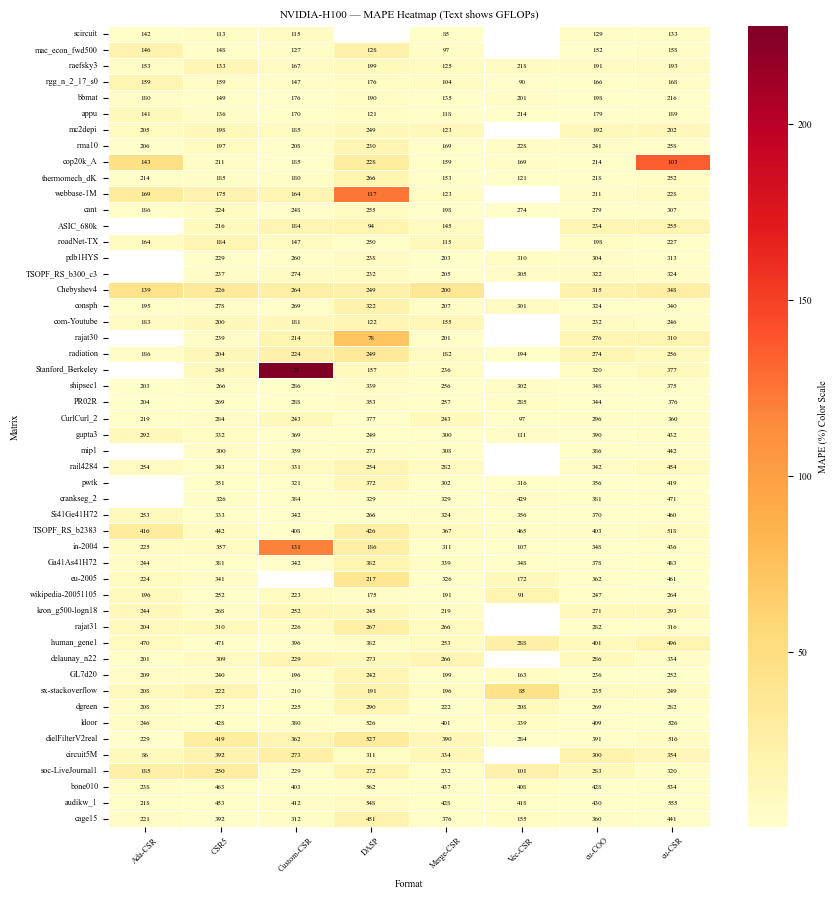


  [Top 10 Matrices with Highest Median Error]
Chebyshev4          27.1
rajat30             17.1
ASIC_680k           16.6
webbase-1M          16.3
soc-LiveJournal1    14.8
circuit5M           13.1
com-Youtube         12.1
radiation           11.2
mc2depi             11.1
kron_g500-logn18    10.8

  [Top 10 Highest Single-Format Errors]
      matrix_name format_name       MAPE
Stanford_Berkeley  Custom-CSR 227.739828
         cop20k_A      cu-CSR 135.890917
       webbase-1M        DASP 124.147084
          in-2004  Custom-CSR 119.104713
          rajat30        DASP  72.230250
         cop20k_A     Ada-CSR  46.498990
 sx-stackoverflow     Vec-CSR  45.647657
       Chebyshev4     Ada-CSR  43.636311
          eu-2005        DASP  38.643065
       Chebyshev4   Merge-CSR  36.606377

  AMD-MI250 — MAPE (%) per Matrix × Format
  -> Saved to ./CSVs/validation_matrix_format_MAPE_AMD-MI250.csv
  -> Saved to ./CSVs/validation_matrix_format_GFLOPS_AMD-MI250.csv


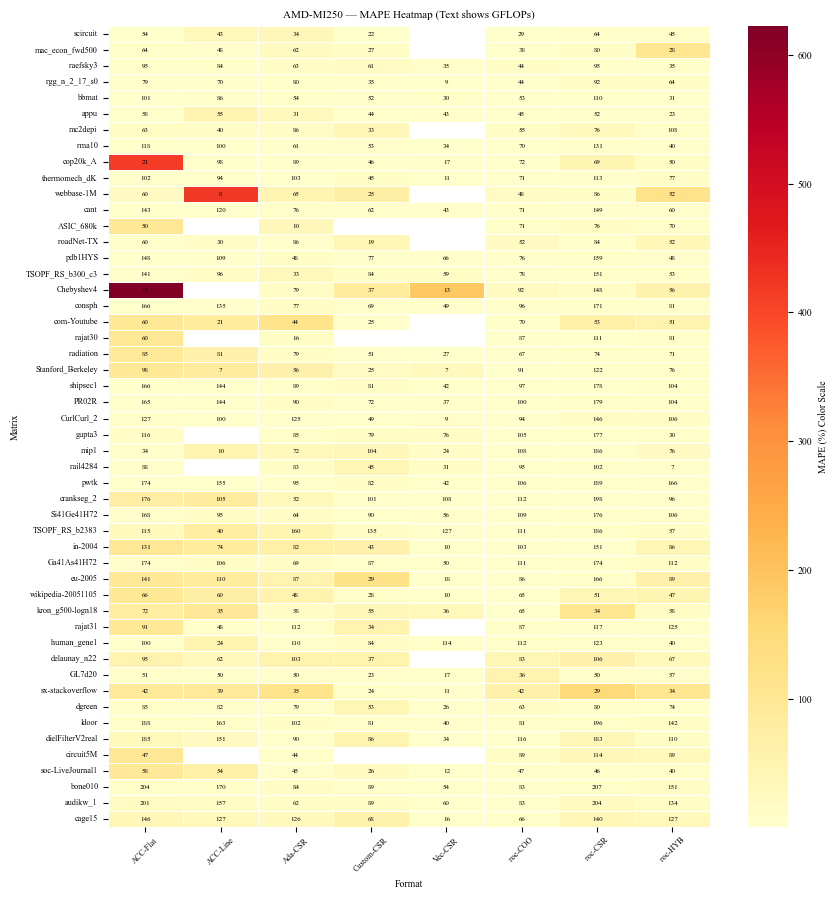


  [Top 10 Matrices with Highest Median Error]
sx-stackoverflow      90.7
com-Youtube           66.0
Chebyshev4            58.2
eu-2005               56.4
delaunay_n22          54.0
in-2004               50.4
webbase-1M            48.3
wikipedia-20051105    43.4
circuit5M             34.1
kron_g500-logn18      33.8

  [Top 10 Highest Single-Format Errors]
     matrix_name format_name       MAPE
      Chebyshev4    ACC-Flat 622.075415
      webbase-1M    ACC-Line 421.264383
        cop20k_A    ACC-Flat 417.978601
      Chebyshev4     Vec-CSR 192.303094
sx-stackoverflow     roc-CSR 151.301493
         eu-2005  Custom-CSR 123.713838
      webbase-1M     roc-HYB 118.538887
     com-Youtube     Ada-CSR 117.081386
sx-stackoverflow     Ada-CSR 114.882927
sx-stackoverflow     roc-HYB 105.839879

  AMD-EPYC-64 — MAPE (%) per Matrix × Format
  -> Saved to ./CSVs/validation_matrix_format_MAPE_AMD-EPYC-64.csv
  -> Saved to ./CSVs/validation_matrix_format_GFLOPS_AMD-EPYC-64.csv


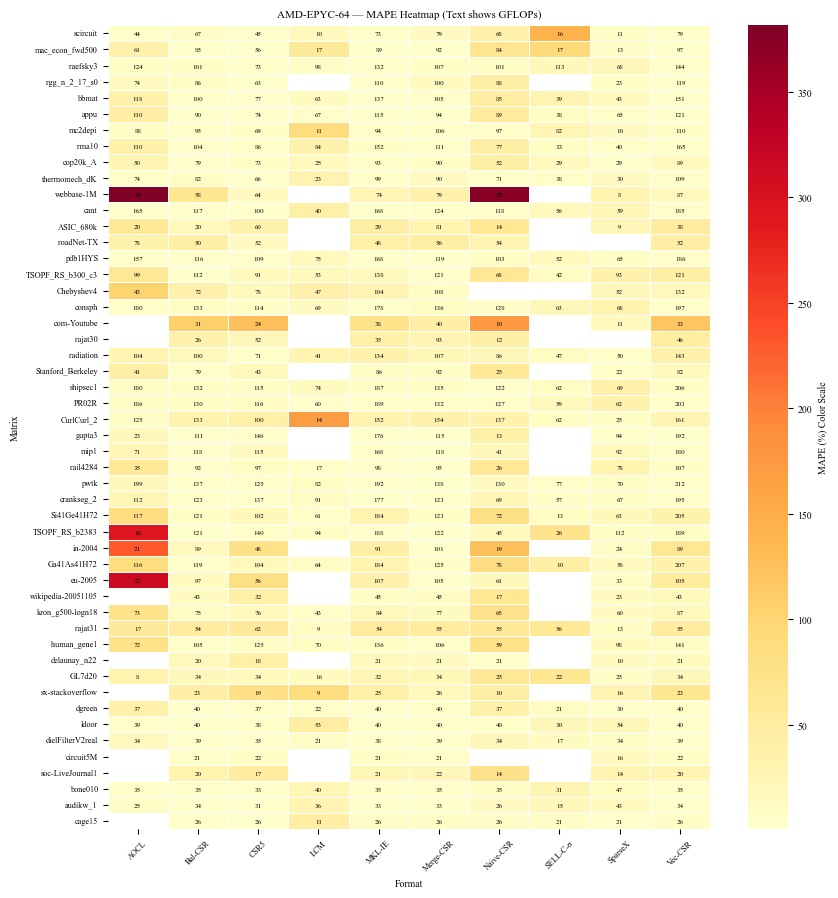


  [Top 10 Matrices with Highest Median Error]
com-Youtube         106.6
in-2004              54.4
rajat31              51.0
sx-stackoverflow     45.3
roadNet-TX           39.6
ASIC_680k            39.0
rajat30              38.0
webbase-1M           34.1
CurlCurl_2           32.5
soc-LiveJournal1     28.9

  [Top 10 Highest Single-Format Errors]
   matrix_name format_name       MAPE
    webbase-1M        AOCL 381.569224
    webbase-1M   Naive-CSR 374.497342
       eu-2005        AOCL 314.785666
TSOPF_RS_b2383        AOCL 295.107876
       in-2004        AOCL 231.086950
   com-Youtube   Naive-CSR 175.531784
    CurlCurl_2         LCM 171.179052
      scircuit    SELL-C-σ 142.074606
   com-Youtube        CSR5 126.905304
       in-2004   Naive-CSR 125.671391

  INTEL-SAPPHIRE-56 — MAPE (%) per Matrix × Format
  -> Saved to ./CSVs/validation_matrix_format_MAPE_INTEL-SAPPHIRE-56.csv
  -> Saved to ./CSVs/validation_matrix_format_GFLOPS_INTEL-SAPPHIRE-56.csv


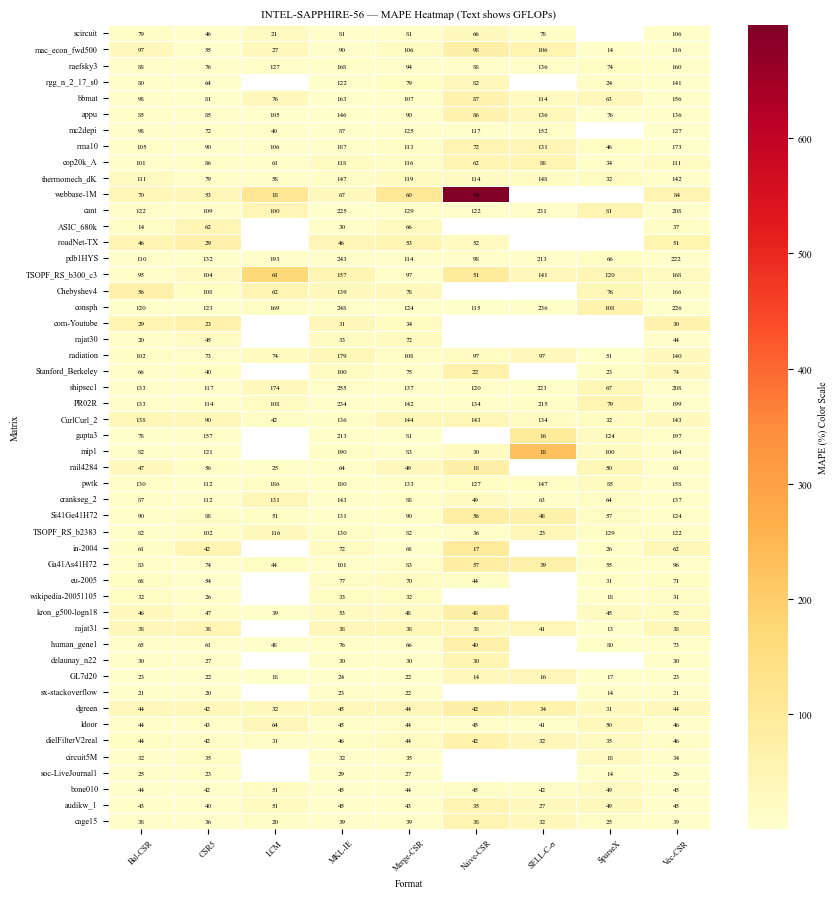


  [Top 10 Matrices with Highest Median Error]
com-Youtube         53.5
webbase-1M          52.4
roadNet-TX          50.7
rajat31             40.9
TSOPF_RS_b300_c3    37.3
dgreen              36.9
Chebyshev4          33.2
CurlCurl_2          32.8
kron_g500-logn18    23.6
in-2004             21.8

  [Top 10 Highest Single-Format Errors]
     matrix_name format_name       MAPE
      webbase-1M   Naive-CSR 697.778873
            mip1    SELL-C-σ 226.655060
TSOPF_RS_b300_c3         LCM 174.297236
      webbase-1M         LCM 113.264272
      webbase-1M   Merge-CSR 108.602790
          gupta3    SELL-C-σ  97.979142
         in-2004   Naive-CSR  97.391986
TSOPF_RS_b300_c3   Naive-CSR  97.381557
     Ga41As41H72   Naive-CSR  83.571790
     Si41Ge41H72   Naive-CSR  80.113469

  ARM-GRACE-72 — MAPE (%) per Matrix × Format
  -> Saved to ./CSVs/validation_matrix_format_MAPE_ARM-GRACE-72.csv
  -> Saved to ./CSVs/validation_matrix_format_GFLOPS_ARM-GRACE-72.csv


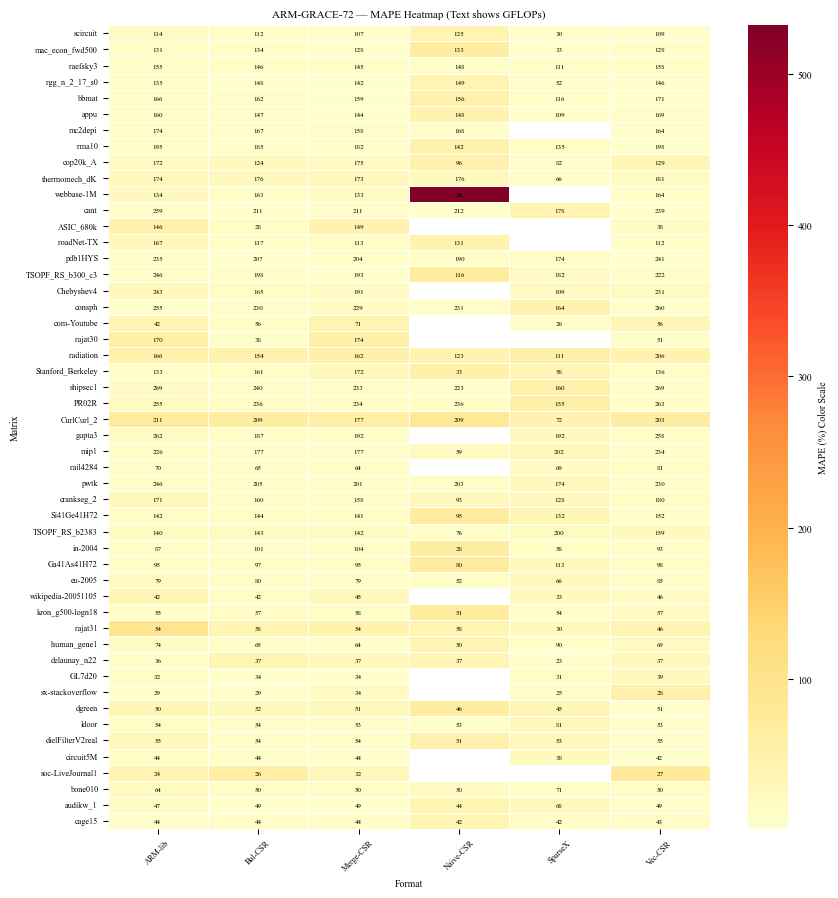


  [Top 10 Matrices with Highest Median Error]
CurlCurl_2          67.5
soc-LiveJournal1    52.3
radiation           51.6
rajat31             41.3
com-Youtube         35.0
rajat30             32.1
dgreen              31.0
ASIC_680k           30.6
delaunay_n22        28.0
thermomech_dK       24.4

  [Top 10 Highest Single-Format Errors]
     matrix_name format_name       MAPE
      webbase-1M   Naive-CSR 532.108413
         rajat31     ARM-lib  92.481688
      CurlCurl_2   Naive-CSR  79.772448
soc-LiveJournal1     Vec-CSR  79.405519
      CurlCurl_2     ARM-lib  73.455099
TSOPF_RS_b300_c3   Naive-CSR  71.658204
kron_g500-logn18   Naive-CSR  70.689759
     Ga41As41H72   Naive-CSR  69.594338
     Si41Ge41H72   Naive-CSR  69.376534
      CurlCurl_2     Bal-CSR  68.800529


In [13]:
# Build and display one pivot table per device for MAPE and GFLOPs
top_avg_all_devices = []
top_single_all_devices = []

for dev in ranges_dev:
    dev_results = results_df[results_df['System'] == dev].copy()
    if dev_results.empty:
        continue
    # Sort matrices by mem_footprint
    mtx_order = dev_results.drop_duplicates('matrix_name').sort_values('mem_footprint')['matrix_name'].values
    
    # ---------------- MAPE Pivot Table ----------------
    pivot = dev_results.pivot_table(index='matrix_name', columns='format_name', values='MAPE', aggfunc='first')
    pivot = pivot.reindex(mtx_order)
    # Add a row-median column and a column-median row
    pivot['ROW_MEDIAN'] = pivot.median(axis=1)
    col_median = pivot.median(axis=0)
    col_median.name = 'COL_MEDIAN'
    pivot = pd.concat([pivot, col_median.to_frame().T])
    pivot = pivot.round(1)
    print(f'\n{"="*80}')
    print(f'  {dev} — MAPE (%) per Matrix × Format')
    print(f'{"="*80}')
    # print(pivot.to_string())
    # Export MAPE
    csv_name = f'./CSVs/validation_matrix_format_MAPE_{dev}.csv'
    pivot.to_csv(csv_name)
    print(f'  -> Saved to {csv_name}')
    
    # ---------------- GFLOPs Pivot Table ----------------
    pivot_gflops = dev_results.pivot_table(index='matrix_name', columns='format_name', values='real_gflops', aggfunc='first')
    pivot_gflops = pivot_gflops.reindex(mtx_order)
    pivot_gflops['ROW_MEDIAN'] = pivot_gflops.median(axis=1)
    col_gflops = pivot_gflops.median(axis=0)
    col_gflops.name = 'COL_MEDIAN'
    pivot_gflops = pd.concat([pivot_gflops, col_gflops.to_frame().T])
    pivot_gflops = pivot_gflops.round(1)
    # Export GFLOPs
    gflops_csv_name = f'./CSVs/validation_matrix_format_GFLOPS_{dev}.csv'
    pivot_gflops.to_csv(gflops_csv_name)
    print(f'  -> Saved to {gflops_csv_name}')

    # ---------------- MAPE Heatmap (Manual Text Overlay) ----------------
    plot_pivot = pivot.drop('COL_MEDIAN', errors='ignore').drop(columns=['ROW_MEDIAN'], errors='ignore')
    plot_pivot_gflops = pivot_gflops.drop('COL_MEDIAN', errors='ignore').drop(columns=['ROW_MEDIAN'], errors='ignore')
    
    # Ensure both dataframes have the exact same shape and ordering
    plot_pivot_gflops = plot_pivot_gflops.reindex_like(plot_pivot)
    
    # Dynamic height calculation
    fig, ax = plt.subplots(figsize=(width*2.5, len(plot_pivot)*0.15 + 1.5))
    
    # 1. Plot the heatmap WITHOUT the built-in annot argument
    sns.heatmap(plot_pivot, annot=False, cmap='YlOrRd', ax=ax, linewidths=0.5, cbar_kws={'label': 'MAPE (%) Color Scale'})
    
    # 2. ALTERNATIVE WAY: Manually loop through rows and columns to inject text
    # This guarantees every single cell gets evaluated and written to the plot
    for i in range(len(plot_pivot.index)):
        for j in range(len(plot_pivot.columns)):
            # Get the raw GFLOPs value
            val = plot_pivot_gflops.iloc[i, j]
            
            # Format text label (leave blank if NaN)
            text = f"{val:.0f}" if pd.notna(val) else ""
            
            # Place text at coordinate (j + 0.5, i + 0.5) to center it in the cell
            # clip_on=True: Prevents rendering outside the bounding box
            ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=5, color='black', clip_on=True)
            
    ax.set_title(f'{dev} — MAPE Heatmap (Text shows GFLOPs)', fontsize=8)
    ax.set_xlabel('Format', fontsize=7)
    ax.set_ylabel('Matrix', fontsize=7)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6, rotation=0)
    
    plt.tight_layout()
    hm_name = f'./Plots/Validation_Matrix_Format_MAPE_heatmap_{dev}.pdf'
    fig.savefig(hm_name, bbox_inches='tight')
    plt.show()
    plt.close()

    # Top 10 matrices with highest median errors
    top_avg = pivot['ROW_MEDIAN'].drop('COL_MEDIAN', errors='ignore').sort_values(ascending=False).head(10)
    print(f'\n  [Top 10 Matrices with Highest Median Error]')
    print(top_avg.to_string())

    df_avg = pd.DataFrame({
        f'{dev}_Matrix': top_avg.index,
        f'{dev}_Error(%)': top_avg.values.round(1)
    }).reset_index(drop=True)
    top_avg_all_devices.append(df_avg)

    # Top 10 matrices with highest single format errors
    top_single = dev_results.sort_values(by='MAPE', ascending=False).head(10)
    print(f'\n  [Top 10 Highest Single-Format Errors]')
    print(top_single[['matrix_name', 'format_name', 'MAPE']].to_string(index=False))

    df_single = pd.DataFrame({
        f'{dev}_Matrix(Format)': top_single['matrix_name'] + ' (' + top_single['format_name'] + ')',
        f'{dev}_Error(%)': top_single['MAPE'].values.round(1)
    }).reset_index(drop=True)
    top_single_all_devices.append(df_single)


In [14]:
# Combine and export top 10 errors across all devices
df_top_avg_all = pd.concat(top_avg_all_devices, axis=1)
df_top_avg_all.to_csv('./CSVs/validation_top10_avg_error_all_devices.csv', index=False)
print('Saved: ./CSVs/validation_top10_avg_error_all_devices.csv')

df_top_single_all = pd.concat(top_single_all_devices, axis=1)
df_top_single_all.to_csv('./CSVs/validation_top10_single_format_error_all_devices.csv', index=False)
print('Saved: ./CSVs/validation_top10_single_format_error_all_devices.csv')


Saved: ./CSVs/validation_top10_avg_error_all_devices.csv
Saved: ./CSVs/validation_top10_single_format_error_all_devices.csv


---
# Summary Tables



In [15]:
# Table 1: Per-device, per-format MAPE + StdDev + CV
fmt_summary = results_df.groupby(['System','format_name']).agg(
    MAPE_median=('MAPE','median'), MAPE_mean=('MAPE','mean'), MAPE_std=('MAPE','std'),
    MedAPE_median=('MedAPE','median'),
    StdDev_mean=('friend_std','mean'), CV_median=('CV','median'), CV_mean=('CV','mean'),
    n_matrices=('matrix_name','nunique'), n_friends_mean=('n_friends','mean')
).reset_index()
fmt_summary = fmt_summary.round(2)

formats_sorted_by_error_list = []

for dev in ranges_dev:
    print(f'\n=== {dev} ===')
    
    # Calculate win share for real matrices on this device
    real_dev = df_real_all[df_real_all['System'] == dev]
    best_formats = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()]['format_name']
    win_counts = best_formats.value_counts()
    total_matrices = len(best_formats)
    win_shares = (win_counts / total_matrices * 100).to_dict()

    dev_df = fmt_summary[fmt_summary['System']==dev].sort_values('MAPE_median', ascending=False)
    dev_df['Win_Share_%'] = dev_df['format_name'].map(win_shares).fillna(0.0).round(1)
    
    print("[Formats Sorted by Highest Median Error]")
    format_names_with_winshare = []
    for i, (_, row) in enumerate(dev_df.iterrows(), 1):
        fmt = row['format_name']
        win_share = win_shares.get(fmt, 0.0)
        fmt_display = f"{fmt} ({win_share:.1f}% wins)"
        format_names_with_winshare.append(fmt_display)
        print(f"  {i}. {fmt_display:<30} median={row['MAPE_median']:.1f}%  mean={row['MAPE_mean']:.1f}%")
        
    # print("\n[Detailed Stats]")
    # print(dev_df.to_string(index=False))

    df_ordered = pd.DataFrame({
        f'{dev}_Format': format_names_with_winshare,
        f'{dev}_MedMAPE(%)': dev_df['MAPE_median'].values,
        f'{dev}_MeanMAPE(%)': dev_df['MAPE_mean'].values
    })
    formats_sorted_by_error_list.append(df_ordered)

df_formats_sorted = pd.concat(formats_sorted_by_error_list, axis=1)
df_formats_sorted.to_csv('./CSVs/validation_formats_sorted_by_error.csv', index=False)



=== NVIDIA-H100 ===
[Formats Sorted by Highest Median Error]
  1. DASP (22.0% wins)              median=12.3%  mean=17.1%
  2. Ada-CSR (2.0% wins)            median=7.5%  mean=10.1%
  3. CSR5 (2.0% wins)               median=5.1%  mean=7.9%
  4. Vec-CSR (4.0% wins)            median=5.0%  mean=7.5%
  5. Custom-CSR (0.0% wins)         median=4.6%  mean=14.0%
  6. cu-CSR (68.0% wins)            median=3.9%  mean=8.2%
  7. cu-COO (2.0% wins)             median=3.7%  mean=5.6%
  8. Merge-CSR (0.0% wins)          median=3.6%  mean=5.8%

=== AMD-MI250 ===
[Formats Sorted by Highest Median Error]
  1. ACC-Line (2.0% wins)           median=13.8%  mean=39.0%
  2. Ada-CSR (2.0% wins)            median=12.3%  mean=23.0%
  3. Custom-CSR (0.0% wins)         median=11.4%  mean=22.5%
  4. roc-HYB (6.0% wins)            median=9.3%  mean=20.6%
  5. roc-CSR (68.0% wins)           median=8.7%  mean=18.2%
  6. ACC-Flat (20.0% wins)          median=7.4%  mean=53.4%
  7. Vec-CSR (0.0% wins)            med

In [16]:
# Table 2: Per-device condensed summary (replaces old Table 4)
dev_summary = results_df.groupby('System').agg(
    MAPE_median=('MAPE','median'),
    MAPE_mean=('MAPE','mean'),
    MAPE_std=('MAPE','std'),
    CV_median=('CV','median'),
    CV_mean=('CV','mean'),
    n_format_matrix_pairs=('matrix_name','count')
).reindex(ranges_dev).reset_index()
dev_summary.loc[len(dev_summary)] = ['Average'] + list(dev_summary.iloc[:,1:].mean())
dev_summary = dev_summary.round(2)
print('\n=== Per-Device Summary (replaces Table 4) ===')
print(f'For GFLOPS_PERCENTILE_THRESHOLD = {GFLOPS_PERCENTILE_THRESHOLD}') 
print(dev_summary.to_string(index=False))


=== Per-Device Summary (replaces Table 4) ===
For GFLOPS_PERCENTILE_THRESHOLD = 5
           System  MAPE_median  MAPE_mean  MAPE_std  CV_median  CV_mean  n_format_matrix_pairs
      NVIDIA-H100         5.04       9.58     17.67       3.11     4.45                  374.0
        AMD-MI250         8.17      24.60     51.36       4.63    11.48                  380.0
      AMD-EPYC-64        12.57      25.18     40.37       5.34     8.69                  453.0
INTEL-SAPPHIRE-56        12.02      22.74     41.52       5.37     8.04                  399.0
     ARM-GRACE-72        12.44      21.40     35.97       6.45     8.85                  283.0
          Average        10.05      20.70     37.38       4.98     8.30                  377.8


In [17]:
# Export CSVs
fmt_summary.to_csv('./CSVs/validation_per_format_detailed.csv', index=False)
dev_summary.to_csv('./CSVs/validation_per_device_summary.csv', index=False)
print('Saved: ./CSVs/validation_per_format_detailed.csv, ./CSVs/validation_per_device_summary.csv')


Saved: ./CSVs/validation_per_format_detailed.csv, ./CSVs/validation_per_device_summary.csv


---
# Plotting: Stacked All-Devices (best-of format, like original Figure 1)



In [18]:
def get_best_format_data(df_real_all, system):
    """Get best-format row per matrix for a device (for the boxplot figure)."""
    real_dev = df_real_all[df_real_all['System']==system].sort_values('mem_footprint')
    best_rows = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()]
    return best_rows.sort_values('mem_footprint')

def plot_stacked_validation(ranges_dev, df_real_all, df_friends_all):
    """Stacked boxplot: one subplot per device, best-of format."""
    font = 7
    fig, axs = plt.subplots(len(ranges_dev))
    fig.subplots_adjust(left=.12, bottom=.17*(2/5)*(4/3.5), right=.99, top=.94)
    validation_meta_all = []
    for ctr, system in enumerate(ranges_dev):
        change_colors([system], color_dictionary)
        best_real = get_best_format_data(df_real_all, system)
        friends_dev = df_friends_all[df_friends_all['System']==system]
        synth_list = []
        for _, row in best_real.iterrows():
            matched = find_friends_for_matrix(row, friends_dev, system)
            # Filter to same format as best real
            fmt = row['format_name']
            matched_fmt = matched[matched['format_name']==fmt]
            if matched_fmt.empty:
                matched_fmt = matched  # fallback: use all formats of friends
                # Take best-of per friend
                dedup_cols = ['nr_rows','nr_cols','nr_nzeros']
                keys = matched_fmt.drop_duplicates(subset=dedup_cols)[dedup_cols]
                best_list = []
                for _, k in keys.iterrows():
                    mask = True
                    for c in dedup_cols:
                        mask = mask & (matched_fmt[c]==k[c])
                    friend_rows = matched_fmt[mask]
                    best_list.append(friend_rows.loc[friend_rows['gflops'].idxmax()])
                matched_fmt = pd.DataFrame(best_list)
            matched_fmt = matched_fmt.copy()
            matched_fmt['matrix_name'] = row['matrix_name']
            synth_list.append(matched_fmt)
        synth_all = pd.concat(synth_list, ignore_index=True)
        sns.boxplot(data=synth_all, x='matrix_name', y='gflops', ax=axs[ctr],
                    fliersize=0.3, linewidth=0.3, color=color_dictionary[system])
        sns.stripplot(data=best_real, x='matrix_name', y='gflops', ax=axs[ctr],
                      color='k', jitter=True, s=3, alpha=0.75, order=best_real['matrix_name'].values)
        # LLC threshold line for CPUs
        arch = best_real['Arch'].iloc[0] if 'Arch' in best_real.columns else ''
        if arch == 'CPU' and system in llc_threshold:
            xtick_items = axs[ctr].get_xticklabels()
            for item in xtick_items:
                mtx = item.get_text()
                me = best_real[best_real['matrix_name']==mtx]
                if me.empty: continue
                me = me.squeeze()
                mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
                if mf > llc_threshold[system]:
                    pos = item.get_position()[0] - 0.5
                    axs[ctr].axvline(x=pos, color='gray', linewidth=0.25)
                    break
        axs[ctr].tick_params(axis='both', which='major', labelsize=font-2)
        axs[ctr].margins(x=0)
        axs[ctr].set_ylabel('')
        if ctr == len(ranges_dev)-1:
            xtick_labels = range(1, len(best_real)+1)
            axs[ctr].set_xlabel('Matrix ID', fontsize=font-1)
            axs[ctr].set_xticks(axs[ctr].get_xticks())
            axs[ctr].set_xticklabels(xtick_labels, fontsize=font-2, rotation=90)
        else:
            axs[ctr].set_xlabel('')
            axs[ctr].set_xticks([])
            axs[ctr].set_xticklabels([])
        axs[ctr].set_ylim([0, axs[ctr].get_ylim()[1]*1.2])
        axs[ctr].text(0.04, 0.85, system, fontsize=font-1, transform=axs[ctr].transAxes)
    fig.text(0.04, 0.5, 'GFLOPs', va='center', rotation='vertical', fontsize=font-1)
    plt.subplots_adjust(wspace=0, hspace=0)
    # for ratio in [0.8, 1, 1.2]:
    for ratio in [1]:
        fig.set_size_inches(width, 1.5*height/(2/5)*ratio*len(ranges_dev)/9)
        fname = f'./Plots/{ratio}_{len(ranges_dev)}_devices_Validation_performat_stacked.pdf'
        fig.savefig(fname, bbox_inches='tight')
        subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        cropped = fname.replace('.pdf','-crop.pdf')
        if os.path.exists(cropped):
            subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()


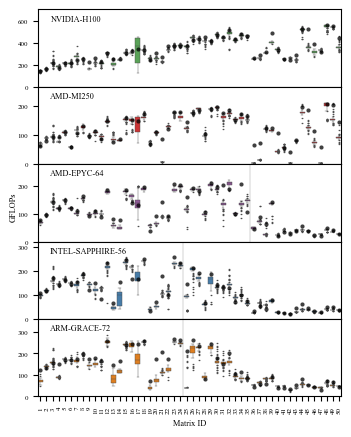

In [19]:
plot_stacked_validation(ranges_dev, df_real_all, df_friends_all)

---
# Per-Device Separate Plots (higher resolution)



In [20]:
def plot_single_device(system, df_real_all, df_friends_all):
    """One plot per device with per-format boxplots."""
    font = 8
    change_colors([system], color_dictionary)
    best_real = get_best_format_data(df_real_all, system)
    friends_dev = df_friends_all[df_friends_all['System']==system]
    synth_list = []
    for _, row in best_real.iterrows():
        matched = find_friends_for_matrix(row, friends_dev, system)
        fmt = row['format_name']
        matched_fmt = matched[matched['format_name']==fmt]
        if matched_fmt.empty:
            dedup_cols = ['nr_rows','nr_cols','nr_nzeros']
            keys = matched.drop_duplicates(subset=dedup_cols)[dedup_cols]
            best_list = []
            for _, k in keys.iterrows():
                mask = True
                for c in dedup_cols: mask = mask & (matched[c]==k[c])
                fr = matched[mask]
                best_list.append(fr.loc[fr['gflops'].idxmax()])
            matched_fmt = pd.DataFrame(best_list)
        matched_fmt = matched_fmt.copy()
        matched_fmt['matrix_name'] = row['matrix_name']
        synth_list.append(matched_fmt)
    synth_all = pd.concat(synth_list, ignore_index=True)
    fig, ax = plt.subplots(1, 1, figsize=(width*2, height*1.2))
    sns.boxplot(data=synth_all, x='matrix_name', y='gflops', ax=ax,
                fliersize=0.5, linewidth=0.5, color=color_dictionary[system])
    sns.stripplot(data=best_real, x='matrix_name', y='gflops', ax=ax,
                  color='k', jitter=True, s=4, alpha=0.85, order=best_real['matrix_name'].values)
    # LLC line
    arch = best_real['Arch'].iloc[0] if 'Arch' in best_real.columns else ''
    if arch == 'CPU' and system in llc_threshold:
        for item in ax.get_xticklabels():
            mtx = item.get_text()
            me = best_real[best_real['matrix_name']==mtx]
            if me.empty: continue
            me = me.squeeze()
            mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
            if mf > llc_threshold[system]:
                ax.axvline(x=item.get_position()[0]-0.5, color='gray', linewidth=0.5, linestyle='--')
                break
    ax.set_title(system, fontsize=font)
    ax.set_xlabel('Matrix', fontsize=font-1)
    ax.set_ylabel('GFLOPs', fontsize=font-1)
    ax.tick_params(axis='x', labelsize=font-2, rotation=90)
    ax.tick_params(axis='y', labelsize=font-2)
    ax.set_ylim([0, ax.get_ylim()[1]*1.15])
    plt.tight_layout()
    fname = f'./Plots/per_format_analysis/Validation_performat_{system}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cropped = fname.replace('.pdf','-crop.pdf')
    if os.path.exists(cropped):
        subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()


In [21]:
# Uncomment to generate per-device plots:
# for dev in ranges_dev:
#     plot_single_device(dev, df_real_all, df_friends_all)


---
# Per-Format, Per-Device Plots (one plot per format per device)
Each plot title includes the aggregate stats for that (device, format) pair.



In [22]:
def plot_single_format_device(system, fmt, df_real_all, df_friends_all, results_df):
    """One plot for a specific (device, format): boxplot of friends + real dot, stats in title."""
    font = 8
    change_colors([system], color_dictionary)
    real_dev = df_real_all[(df_real_all['System']==system)].sort_values('mem_footprint')
    friends_dev = df_friends_all[df_friends_all['System']==system]

    # Only keep matrices that have this format in the real data
    real_fmt = real_dev[real_dev['format_name']==fmt].sort_values('mem_footprint')
    if real_fmt.empty:
        return
    matrix_order = real_fmt['matrix_name'].values

    # Build boxplot data: for each matrix, find feature-matched friends filtered to this format
    synth_list = []
    for _, row in real_fmt.iterrows():
        matched = find_friends_for_matrix(row, friends_dev, system)
        matched_fmt = matched[matched['format_name']==fmt].copy()
        if matched_fmt.empty:
            continue
        matched_fmt['matrix_name'] = row['matrix_name']
        synth_list.append(matched_fmt)

    if not synth_list:
        print(f'  Skipping {system} / {fmt}: no friends found for any matrix')
        return
    synth_all = pd.concat(synth_list, ignore_index=True)

    # Retrieve aggregate stats from results_df
    stats = results_df[(results_df['System']==system) & (results_df['format_name']==fmt)]
    if stats.empty:
        return
    agg_mape = stats['MAPE'].mean()
    agg_std = stats['friend_std'].mean()
    agg_cv = stats['CV'].mean()
    n_mtx = stats['matrix_name'].nunique()
    n_friends_avg = stats['n_friends'].mean()

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(width*2, height*1.2))
    # Only plot matrices that have friends
    matrices_with_friends = synth_all['matrix_name'].unique()
    plot_order = [m for m in matrix_order if m in matrices_with_friends]
    sns.boxplot(data=synth_all, x='matrix_name', y='gflops', ax=ax, order=plot_order,
                fliersize=0.5, linewidth=0.5, color=color_dictionary[system])
    # Real dots (filter to matrices with friends)
    real_plot = real_fmt[real_fmt['matrix_name'].isin(plot_order)]
    sns.stripplot(data=real_plot, x='matrix_name', y='gflops', ax=ax,
                  color='k', jitter=True, s=4, alpha=0.85, order=plot_order)

    # LLC line for CPUs
    arch = real_fmt['Arch'].iloc[0] if 'Arch' in real_fmt.columns else ''
    if arch == 'CPU' and system in llc_threshold:
        for item in ax.get_xticklabels():
            mtx = item.get_text()
            me = real_fmt[real_fmt['matrix_name']==mtx]
            if me.empty: continue
            me = me.squeeze()
            mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
            if mf > llc_threshold[system]:
                ax.axvline(x=item.get_position()[0]-0.5, color='gray', linewidth=0.5, linestyle='--')
                break

    title_str = (f'{system}  —  {fmt}\n'
                 f'MAPE={agg_mape:.1f}%   StdDev={agg_std:.1f} GFLOPs   '
                 f'CV={agg_cv:.1f}%   #matrices={n_mtx}   '
                 f'avg #friends={n_friends_avg:.0f}')
    ax.set_title(title_str, fontsize=font-0.5)
    ax.set_xlabel('Matrix', fontsize=font-1)
    ax.set_ylabel('GFLOPs', fontsize=font-1)
    ax.tick_params(axis='x', labelsize=font-2, rotation=90)
    ax.tick_params(axis='y', labelsize=font-2)
    ax.set_ylim([0, ax.get_ylim()[1]*1.15])
    plt.tight_layout()
    fmt_safe = fmt.replace('/', '_').replace(' ', '_')
    fname = f'./Plots/per_format_analysis/Validation_{system}_{fmt_safe}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cropped = fname.replace('.pdf','-crop.pdf')
    if os.path.exists(cropped):
        subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()


In [23]:
# Uncomment to generate per-format per-device plots (generates ~50 PDFs):
# for dev in ranges_dev:
#     dev_formats = sorted(results_df[results_df['System']==dev]['format_name'].unique())
#     for fmt in dev_formats:
#         plot_single_format_device(dev, fmt, df_real_all, df_friends_all, results_df)


---
# Spread Analysis: CV / StdDev Heatmap



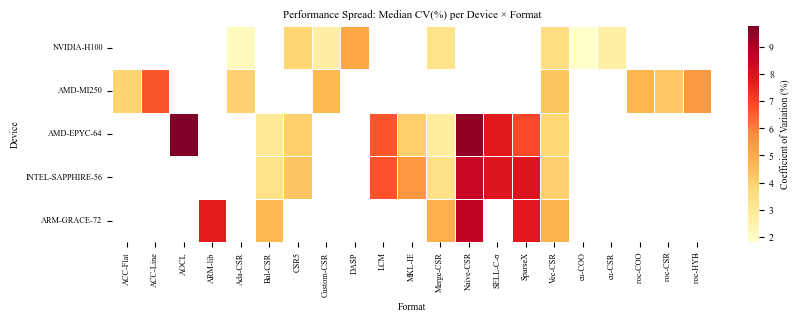

In [24]:
# Heatmap: CV per (device, format) — using MEDIAN
pivot_cv = results_df.groupby(['System','format_name'])['CV'].median().reset_index()
pivot_cv = pivot_cv.pivot(index='System', columns='format_name', values='CV')
pivot_cv = pivot_cv.reindex(ranges_dev)

fig, ax = plt.subplots(figsize=(width*2.5, height*1.5))
sns.heatmap(pivot_cv, annot=False, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Coefficient of Variation (%)'})
ax.set_title('Performance Spread: Median CV(%) per Device × Format', fontsize=8)
ax.set_xlabel('Format', fontsize=7)
ax.set_ylabel('Device', fontsize=7)
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('./Plots/Validation_CV_heatmap.pdf', bbox_inches='tight')
plt.show()

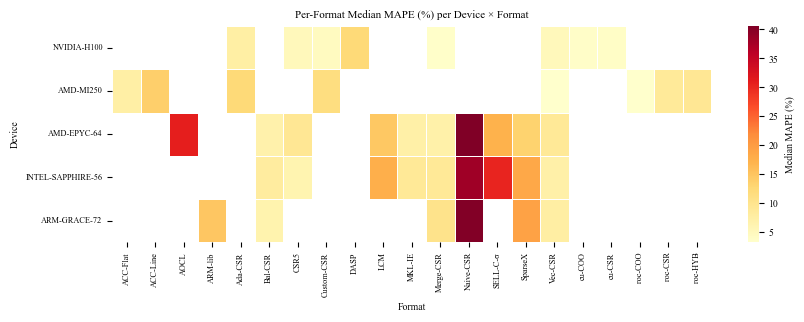

In [25]:
# Heatmap: MAPE per (device, format) — using MEDIAN
pivot_mape = results_df.groupby(['System','format_name'])['MAPE'].median().reset_index()
pivot_mape = pivot_mape.pivot(index='System', columns='format_name', values='MAPE')
pivot_mape = pivot_mape.reindex(ranges_dev)

fig, ax = plt.subplots(figsize=(width*2.5, height*1.5))
sns.heatmap(pivot_mape, annot=False, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Median MAPE (%)'})
ax.set_title('Per-Format Median MAPE (%) per Device × Format', fontsize=8)
ax.set_xlabel('Format', fontsize=7)
ax.set_ylabel('Device', fontsize=7)
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('./Plots/Validation_MAPE_heatmap.pdf', bbox_inches='tight')
plt.show()

In [26]:
# Print overall summary
print('\n' + '='*60)
print('OVERALL SUMMARY')
print('='*60)
print(f'Overall Median MAPE:   {results_df["MAPE"].median():.2f}%')
print(f'Overall Mean MAPE:     {results_df["MAPE"].mean():.2f}%')
print(f'Overall Median MedAPE: {results_df["MedAPE"].median():.2f}%')
print(f'Overall Median CV:     {results_df["CV"].median():.2f}%')
print(f'Overall Mean CV:       {results_df["CV"].mean():.2f}%')
print(f'Overall Mean StdDev:   {results_df["friend_std"].mean():.2f} GFLOPs')
print()
print('Per-device breakdown:')
for dev in ranges_dev:
    d = results_df[results_df['System']==dev]
    print(f'  {dev:25s}  MedMAPE={d["MAPE"].median():6.2f}%  MeanMAPE={d["MAPE"].mean():6.2f}%  MedCV={d["CV"].median():5.2f}%')


OVERALL SUMMARY
Overall Median MAPE:   9.07%
Overall Mean MAPE:     20.89%
Overall Median MedAPE: 8.22%
Overall Median CV:     4.66%
Overall Mean CV:       8.30%
Overall Mean StdDev:   6.57 GFLOPs

Per-device breakdown:
  NVIDIA-H100                MedMAPE=  5.04%  MeanMAPE=  9.58%  MedCV= 3.11%
  AMD-MI250                  MedMAPE=  8.17%  MeanMAPE= 24.60%  MedCV= 4.63%
  AMD-EPYC-64                MedMAPE= 12.57%  MeanMAPE= 25.18%  MedCV= 5.34%
  INTEL-SAPPHIRE-56          MedMAPE= 12.02%  MeanMAPE= 22.74%  MedCV= 5.37%
  ARM-GRACE-72               MedMAPE= 12.44%  MeanMAPE= 21.40%  MedCV= 6.45%
